# Porto Seguro Data Set EDA Notebook

### 1. Initial Setup, Configurations and Data Load

In [1]:
#!pip install catboost
#!pip install lightgbm
#pip install xgboost

In [2]:
#-------------------------------------------------------------
# 1.1 Setup
#-------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
import warnings
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from scipy.stats import spearmanr
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc as sklearn_auc, average_precision_score, brier_score_loss
#from sklearn.metrics import auc, 
from sklearn.calibration import calibration_curve, IsotonicRegression
from sklearn.utils import resample
import joblib
import os


In [3]:
#-------------------------------------------------------------
# 1.2 set config
#-------------------------------------------------------------
# Pandas
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_columns', 10)  
pd.set_option('display.max_colwidth', 15) 
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Python
# pretty print
pp = pprint.PrettyPrinter(indent=4)

# Warnings handle
warnings.filterwarnings('ignore')

In [4]:
#-------------------------------------------------------------
# 1.3 Load Dataset
#-------------------------------------------------------------
df=pd.read_csv("train.csv")

print("Shape of dataset:", df.shape)
pd.set_option('display.max_columns', 59)  
display(df.head(3))

Shape of dataset: (595212, 59)


,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,ps_ind_10_bin,ps_ind_11_bin,ps_ind_12_bin,ps_ind_13_bin,ps_ind_14,ps_ind_15,ps_ind_16_bin,ps_ind_17_bin,ps_ind_18_bin,ps_reg_01,ps_reg_02,ps_reg_03,ps_car_01_cat,ps_car_02_cat,ps_car_03_cat,ps_car_04_cat,ps_car_05_cat,ps_car_06_cat,ps_car_07_cat,ps_car_08_cat,ps_car_09_cat,ps_car_10_cat,ps_car_11_cat,ps_car_11,ps_car_12,ps_car_13,ps_car_14,ps_car_15,ps_calc_01,ps_calc_02,ps_calc_03,ps_calc_04,ps_calc_05,ps_calc_06,ps_calc_07,ps_calc_08,ps_calc_09,ps_calc_10,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,0,0,0,0,0,0,11,0,1,0,0.7,0.2,0.718070,10,1,-1,0,1,4,1,0,0,1,12,2,0.400000,0.883679,0.370810,3.605551,0.6,0.5,0.2,3,1,10,1,10,1,5,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,0,0,0,0,0,0,3,0,0,1,0.8,0.4,0.766078,11,1,-1,0,-1,11,1,1,2,1,19,3,0.316228,0.618817,0.388716,2.449490,0.3,0.1,0.3,2,1,9,5,8,1,7,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,0,0,0,0,0,0,12,1,0,0,0.0,0.0,-1.000000,7,1,-1,0,-1,14,1,1,2,1,60,1,0.316228,0.641586,0.347275,3.316625,0.5,0.7,0.1,2,2,9,1,8,2,7,4,2,7,7,0,1,1,0,1,0


In [5]:
#-------------------------------------------------------------
# 1.4 Basic Info
# ------------------------------------------------------------
print(df.info())
print("\nSummary statistics (numeric features):")
display(df.describe().T)  #display(df.describe().T.head(10))

pd.set_option('display.max_columns', 10)  
pd.set_option('display.max_colwidth', 15) 

# Feature type counts (binary, categorical, continuous)
#-------------------------------------------------------------
binary_cols = [col for col in df.columns if col.endswith('_bin')]
categorical_cols = [col for col in df.columns if col.endswith('_cat')]
continuous_cols = [col for col in df.columns if col not in binary_cols + categorical_cols + ['id', 'target']]


print(f"Binary features: {len(binary_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Continuous features: {len(continuous_cols)}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

,count,mean,std,min,25%,50%,75%,max
id,595212.0,743803.558435,429367.820429,7.000000,371991.500000,743547.500000,1.115549e+06,1.488027e+06
target,595212.0,0.036448,0.187401,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00
ps_ind_01,595212.0,1.900378,1.983789,0.000000,0.000000,1.000000,3.000000e+00,7.000000e+00
ps_ind_02_cat,595212.0,1.358943,0.664594,-1.000000,1.000000,1.000000,2.000000e+00,4.000000e+00
ps_ind_03,595212.0,4.423318,2.699902,0.000000,2.000000,4.000000,6.000000e+00,1.100000e+01
ps_ind_04_cat,595212.0,0.416794,0.493311,-1.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
ps_ind_05_cat,595212.0,0.405188,1.350642,-1.000000,0.000000,0.000000,0.000000e+00,6.000000e+00
ps_ind_06_bin,595212.0,0.393742,0.488579,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
ps_ind_07_bin,595212.0,0.257033,0.436998,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
ps_ind_08_bin,595212.0,0.163921,0.370205,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00


Binary features: 17
Categorical features: 14
Continuous features: 26


### Summary
</br>
In the train and test data, features that belong to similar groupings are tagged as such in the feature names (e.g., ind, reg, car, calc). In addition, feature names include the postfix bin to indicate binary features and cat to indicate categorical features. Features without these designations are either continuous or ordinal.

* target column: 1="claim was filed"  0= "not insurance claim" filed for that policy holder.
* ind is related to individual or driver
* reg is related to region
* car is related to car itself
* calc is an calculated feature
* -1 values indicate that the feature was missing

### 2. Target Distribution


Target Distribution (%):
 target
0    96.355248
1     3.644752
Name: proportion, dtype: float64


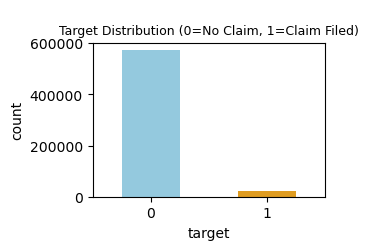

In [6]:
#-------------------------------------------------------------
# 2.1 Target Distribution Analysis
# ------------------------------------------------------------
target_counts=df['target'].value_counts(normalize=True) * 100
print("\nTarget Distribution (%):\n", target_counts)

plt.figure(figsize=(3,2))
sns.countplot(x='target', data=df, width=0.5,   palette=['skyblue', 'orange'])
plt.title("\nTarget Distribution (0=No Claim, 1=Claim Filed)", fontsize=9)
plt.show()


### 3. Missing Values Check


Missing Values Overview (-1 treated as missing):


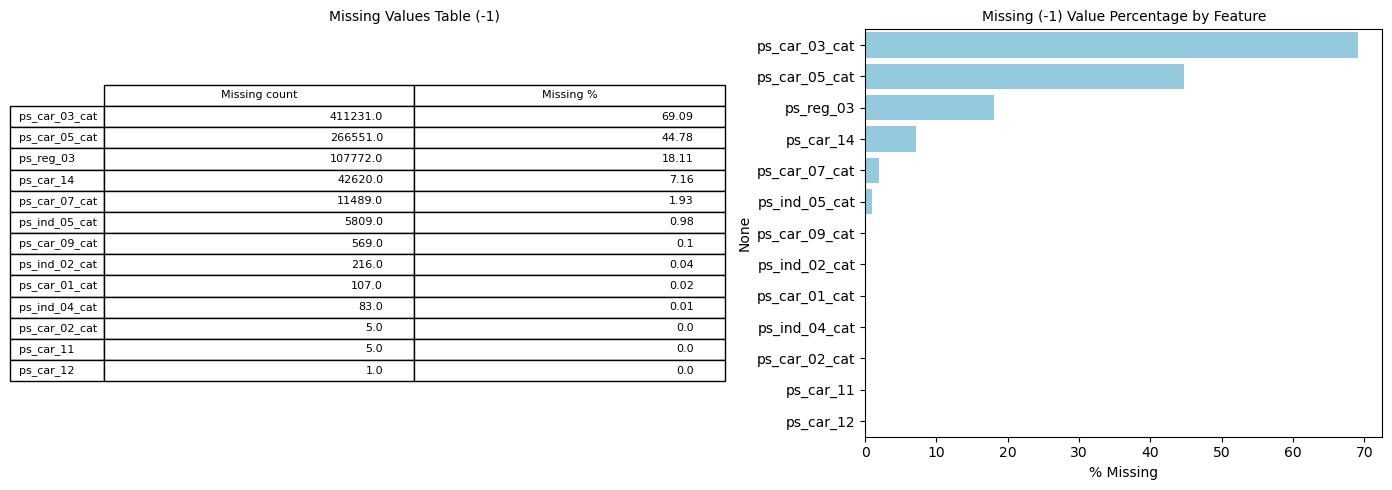

In [7]:
#-------------------------------------------------------------
# 3.1 Missing Values (-1 treated as missing)
#-------------------------------------------------------------
missing = (df == -1).sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_prct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing count": missing, "Missing %": missing_prct})

print("\nMissing Values Overview (-1 treated as missing):")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# TABLO (ax[0])
ax[0].axis('off')
tbl = ax[0].table(
    cellText=missing_df.round(2).values,
    colLabels=missing_df.columns,
    rowLabels=missing_df.index,
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.2, 1.2)
ax[0].set_title("Missing Values Table (-1)", fontsize=10)

# GRAFİK (ax[1])
sns.barplot(x=missing_prct, y=missing_prct.index, ax=ax[1], color='skyblue')
ax[1].set_title("Missing (-1) Value Percentage by Feature", fontsize=10)
ax[1].set_xlabel("% Missing")

plt.tight_layout()
plt.show()


### 4. Feature Analysis

In [8]:
#------------------------------------------------------------
# 4.1 Feature type counts (binary, categorical, continuous)
#------------------------------------------------------------
binary_cols = [col for col in df.columns if col.endswith('_bin')]
categorical_cols = [col for col in df.columns if col.endswith('_cat')]
continuous_cols = [col for col in df.columns if col not in binary_cols + categorical_cols + ['id', 'target']]

print("=" * 50)
print(f"Binary features: {len(binary_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Continuous features: {len(continuous_cols)}")


Binary features: 17
Categorical features: 14
Continuous features: 26



Distribution of Binary Features:
       Feature  Zeros   Ones  Ratio_1s    Balance
 ps_ind_16_bin 201882 393330  0.660823   Balanced
ps_calc_16_bin 221514 373698  0.627840   Balanced
ps_calc_17_bin 265356 329856  0.554182   Balanced
 ps_ind_06_bin 360852 234360  0.393742   Balanced
ps_calc_19_bin 387469 207743  0.349024   Balanced
ps_calc_18_bin 424278 170934  0.287182 Imbalanced
 ps_ind_07_bin 442223 152989  0.257033 Imbalanced
 ps_ind_09_bin 484917 110295  0.185304 Imbalanced
 ps_ind_08_bin 497644  97568  0.163921 Imbalanced
 ps_ind_18_bin 503879  91333  0.153446 Imbalanced
ps_calc_20_bin 503955  91257  0.153318 Imbalanced
ps_calc_15_bin 522342  72870  0.122427 Imbalanced
 ps_ind_17_bin 523143  72069  0.121081 Imbalanced
 ps_ind_12_bin 589594   5618  0.009439 Imbalanced
 ps_ind_11_bin 594205   1007  0.001692 Imbalanced
 ps_ind_13_bin 594648    564  0.000948 Imbalanced
 ps_ind_10_bin 594990    222  0.000373 Imbalanced


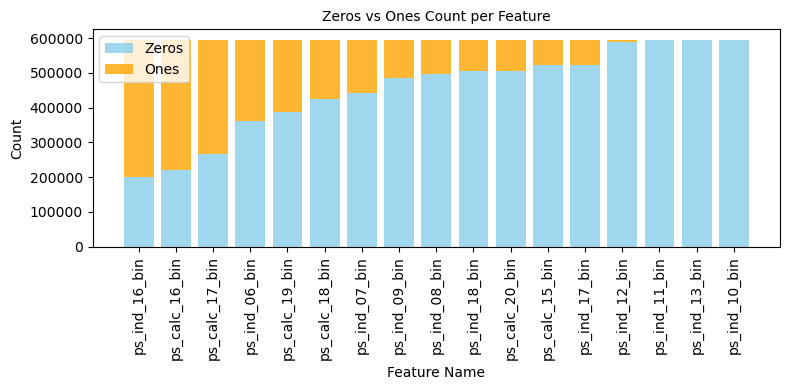

In [9]:
#------------------------------------------------------------
# 4.2 Binary Feature Analysis
#------------------------------------------------------------
bin_distribution = pd.DataFrame({
    'Feature': binary_cols,
    'Zeros': [df[col].value_counts().get(0, 0) for col in binary_cols],
    'Ones': [df[col].value_counts().get(1, 0) for col in binary_cols],
    'Ratio_1s': [df[col].mean() for col in binary_cols]
})

bin_distribution['Balance'] = bin_distribution['Ratio_1s'].apply(
    lambda x: 'Balanced' if 0.3 <= x <= 0.7 else 'Imbalanced'
)

bin_distribution = bin_distribution.sort_values('Ratio_1s', ascending=False)

print("\nDistribution of Binary Features:")
print(bin_distribution.to_string(index=False))


plt.figure(figsize=(8, 4))

zeros = bin_distribution['Zeros']
ones = bin_distribution['Ones']
features = bin_distribution['Feature']

plt.bar(features, zeros, label='Zeros', color='skyblue', alpha=0.8)
plt.bar(features, ones, bottom=zeros, label='Ones', color='orange',alpha=0.8)

plt.xticks(rotation=90)
plt.title("Zeros vs Ones Count per Feature",  fontsize=10)
plt.xlabel("Feature Name")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()



----------------------------------------------------------------------
  Categorical Feature Analysis
----------------------------------------------------------------------

Categorical Feature Statistics:
      Feature  Cardinality  Missing_Pct  Most_Common  Most_Common_Freq
ps_car_11_cat          104     0.000000          104         14.294571
ps_car_06_cat           18     0.000000           11         22.097505
ps_car_01_cat           13     0.017977           11         34.873793
ps_car_04_cat           10     0.000000            0         83.429266
ps_ind_05_cat            8     0.975955            0         88.709401
ps_car_09_cat            6     0.095596            2         59.387580
ps_ind_02_cat            5     0.036290            1         72.555493
ps_ind_04_cat            3     0.013945            0         58.292676
ps_car_02_cat            3     0.000840            1         82.993958
ps_car_03_cat            3    69.089837           -1         69.089837
ps_car_05_ca

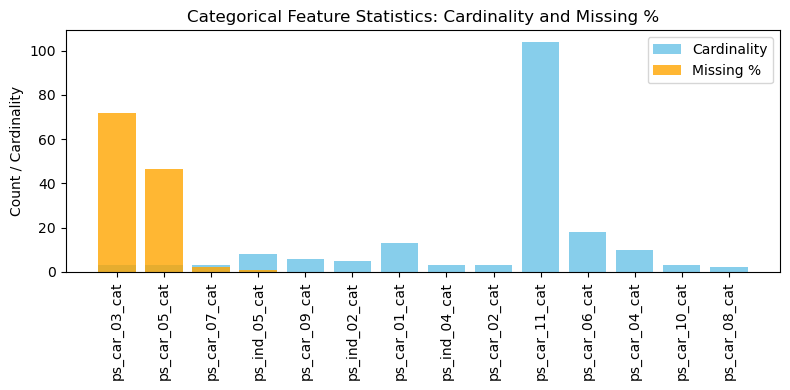


Classification by Cardinality:
Cardinality_Type
Low (≤10)         11
Medium (11-50)     2
High (>50)         1
Name: count, dtype: int64


In [10]:
#-------------------------------------------------------------
# 4.3 Categorical Feature Analysis
# ------------------------------------------------------------
print("\n" + "-"*70)
print("  Categorical Feature Analysis")
print("-"*70)

# Cardinality and statistics
cat_stats = pd.DataFrame({
    'Feature': categorical_cols,
    'Cardinality': [df[col].nunique() for col in categorical_cols],
    'Missing_Pct': [(df[col] == -1).sum() / len(df) * 100 for col in categorical_cols],
    'Most_Common': [df[col].mode()[0] if len(df[col].mode()) > 0 else None for col in categorical_cols],
    'Most_Common_Freq': [df[col].value_counts().iloc[0] / len(df) * 100 for col in categorical_cols]
})

# Sort by cardinality descending
cat_stats = cat_stats.sort_values('Cardinality', ascending=False)

print("\nCategorical Feature Statistics:")
print(cat_stats.to_string(index=False))

# Sort features by Missing_Pct descending for readability
cat_stats_sorted = cat_stats.sort_values('Missing_Pct', ascending=False)
features = cat_stats_sorted['Feature']
missing_pct = cat_stats_sorted['Missing_Pct']
cardinality = cat_stats_sorted['Cardinality']

plt.figure(figsize=(8,4))

# Base bar: Cardinality
bars = plt.bar(features, cardinality, color='skyblue', label='Cardinality')

# Overlay missing % as red transparent bar
plt.bar(features, missing_pct * max(cardinality)/100, color='orange', alpha=0.8, label='Missing %')

plt.xticks(rotation=90)
plt.ylabel("Count / Cardinality")
plt.title("Categorical Feature Statistics: Cardinality and Missing %")
plt.legend()
plt.tight_layout()
plt.show()
# Classify by cardinality
cat_stats['Cardinality_Type'] = cat_stats['Cardinality'].apply(
    lambda x: 'Low (≤10)' if x <= 10 else ('Medium (11-50)' if x <= 50 else 'High (>50)')
)

print("\nClassification by Cardinality:")
print(cat_stats['Cardinality_Type'].value_counts())


In [11]:
#--------------------------------------------
# 4.4 Numerical Feature Analysis
# -------------------------------------------
print("\n" + "-"*70)
print("  Numerical Feature Analysis")
print("-"*70)

# Base descriptive statistics
num_stats = df[continuous_cols].describe().T

# Additional metrics
num_stats["cardinality"] = df[continuous_cols].nunique()
num_stats["skewness"] = df[continuous_cols].skew()
num_stats["kurtosis"] = df[continuous_cols].kurtosis()
num_stats["missing_pct"] = (df[continuous_cols] == -1).sum() / len(df) * 100

# Final clean output
print("\nDescriptive Statistics of Numerical Features:")
print(
    num_stats[
        ["cardinality", "mean", "std", "min", "max", "skewness", "kurtosis", "missing_pct"]
    ].round(3)
)



----------------------------------------------------------------------
  Numerical Feature Analysis
----------------------------------------------------------------------

Descriptive Statistics of Numerical Features:
            cardinality   mean    std    min     max  skewness  kurtosis  missing_pct
ps_ind_01             8  1.900  1.984  0.000   7.000     0.932    -0.219        0.000
ps_ind_03            12  4.423  2.700  0.000  11.000     0.464    -0.650        0.000
ps_ind_14             5  0.012  0.128  0.000   4.000    12.208   180.698        0.000
ps_ind_15            14  7.300  3.546  0.000  13.000    -0.286    -0.736        0.000
ps_reg_01            10  0.611  0.288  0.000   0.900    -0.639    -0.887        0.000
ps_reg_02            19  0.439  0.404  0.000   1.800     1.281     1.124        0.000
ps_reg_03          5013  0.551  0.794 -1.000   4.038    -1.013     0.086       18.106
ps_car_11             5  2.346  0.833 -1.000   3.000    -1.173     0.668        0.001
ps_car_

In [12]:
#-------------------------------------------------------------
# 4.5 Numerical Features
# Ordinal vs Real Continuous split (cardinality-based)
#-------------------------------------------------------------
ordinal_columns = num_stats[num_stats["cardinality"] <= 30].index.tolist()
real_continuous_columns = num_stats[num_stats["cardinality"] > 30].index.tolist()

print("\n--> ORDINAL Columns:")
print(ordinal_columns)

print("\n--> REAL CONTINUOUS Columns:")
print(real_continuous_columns)



--> ORDINAL Columns:
['ps_ind_01', 'ps_ind_03', 'ps_ind_14', 'ps_ind_15', 'ps_reg_01', 'ps_reg_02', 'ps_car_11', 'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04', 'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09', 'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14']

--> REAL CONTINUOUS Columns:
['ps_reg_03', 'ps_car_12', 'ps_car_13', 'ps_car_14']



----------------------------------------------------------------------
  Ordinal Feature Analysis
----------------------------------------------------------------------

Ordinal Features Statistics (Skew, Kurtosis, Missing, Cardinality):
       Feature  Skewness  Kurtosis  Missing_Pct  Cardinality
2    ps_ind_14    12.208   180.698        0.000            5
6    ps_car_11    -1.173     0.668        0.001            5
11  ps_calc_04     0.044    -0.404        0.000            6
12  ps_calc_05     0.329    -0.221        0.000            7
0    ps_ind_01     0.932    -0.219        0.000            8
16  ps_calc_09     0.262    -0.224        0.000            8
14  ps_calc_07     0.233    -0.175        0.000           10
9   ps_calc_02     0.001    -1.220        0.000           10
10  ps_calc_03     0.001    -1.224        0.000           10
4    ps_reg_01    -0.639    -0.887        0.000           10
8   ps_calc_01    -0.001    -1.225        0.000           10
13  ps_calc_06    -0.408    -

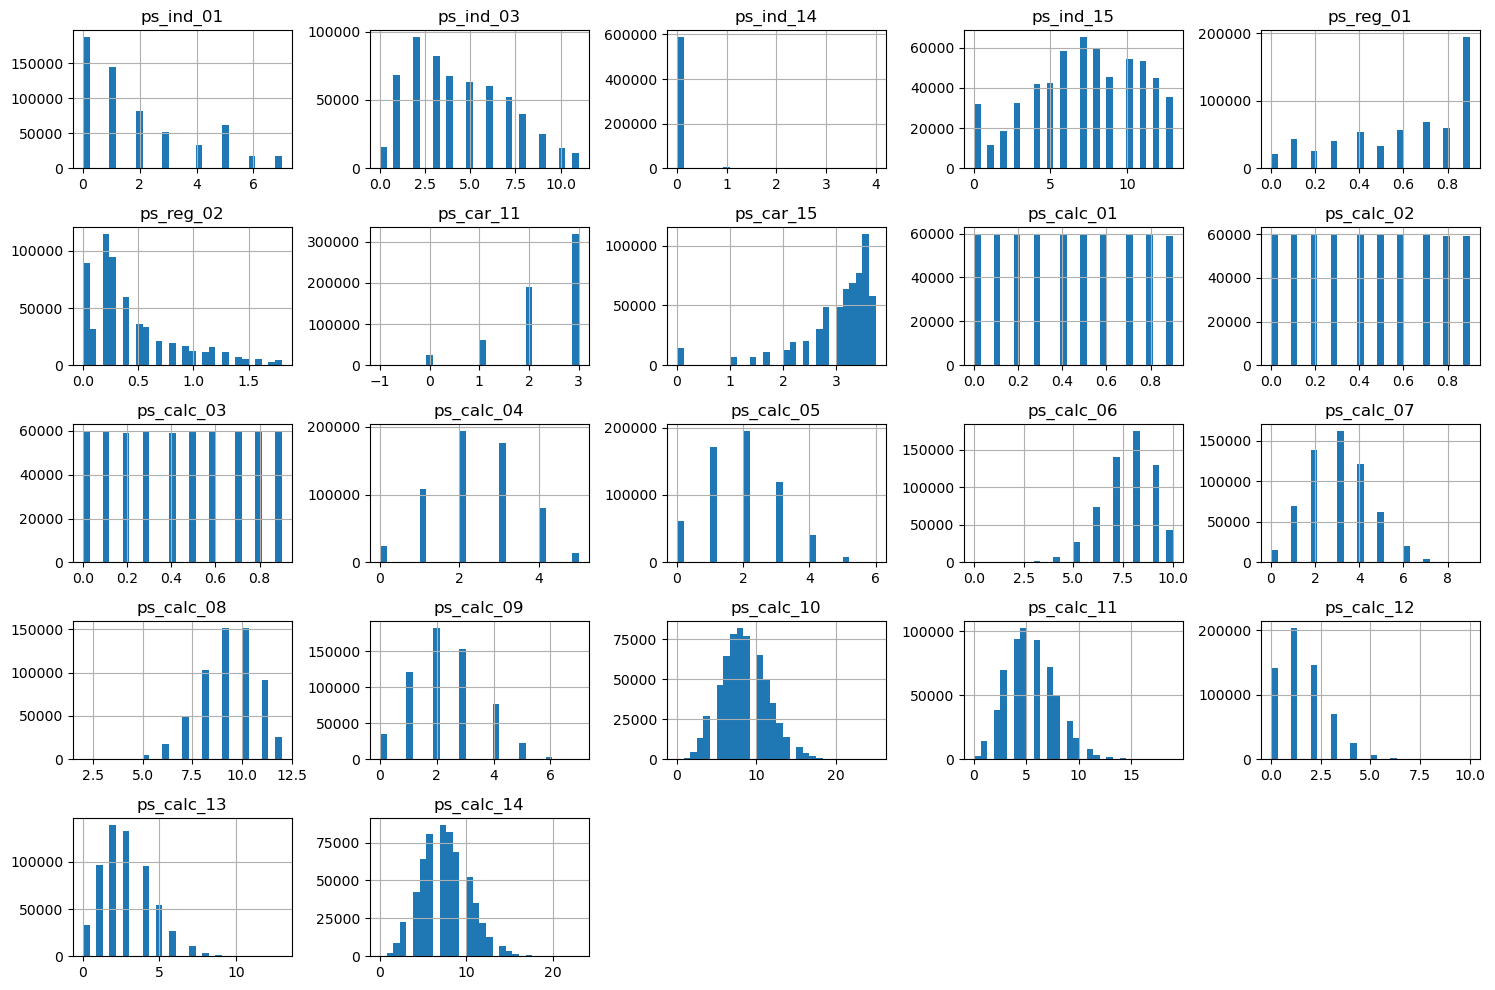

In [13]:
#-----------------------------------------------------------------
# 4.6 Ordinal Feature Analysis
# Note: Rare classes are only reported here.
# Actual collapsing is performed later with a stricter threshold.
# -----------------------------------------------------------------
print("\n" + "-"*70)
print("  Ordinal Feature Analysis")
print("-"*70)

# 1) Calculating Skewness & kurtosis
ordinal_stats = pd.DataFrame({
    'Feature': ordinal_columns, # ordinal_candidates,
    'Skewness': [df[col].skew() for col in ordinal_columns],
    'Kurtosis': [df[col].kurtosis() for col in ordinal_columns],
    'Missing_Pct': [(df[col] == -1).sum() / len(df) * 100 for col in ordinal_columns],
    'Cardinality': [df[col].nunique() for col in ordinal_columns]
}).sort_values('Cardinality')

print("\nOrdinal Features Statistics (Skew, Kurtosis, Missing, Cardinality):")
print(ordinal_stats.round(3))

# 2) Checking Rare Classes
rare_threshold = 0.05  # classes less than %5
for col in ordinal_columns:
    value_counts = df[col].value_counts(normalize=True)
    rare_classes = value_counts[value_counts < rare_threshold]
    if len(rare_classes) > 0:
        print(f"\n--> Rare classes in {col}:")
        print(rare_classes)

# Histograms for continuous features
df[ordinal_columns].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()



Real Continuous Features Statistics (Skew, Kurtosis, Missing):
     Feature   Mean    Std    Min    Max  Skewness  Kurtosis  Missing_Pct
2  ps_car_13  0.813  0.225  0.251  3.721     1.701     5.422        0.000
1  ps_car_12  0.380  0.058 -1.000  1.265     1.067     5.495        0.000
0  ps_reg_03  0.551  0.794 -1.000  4.038    -1.013     0.086       18.106
3  ps_car_14  0.276  0.357 -1.000  0.636    -3.234     8.690        7.160


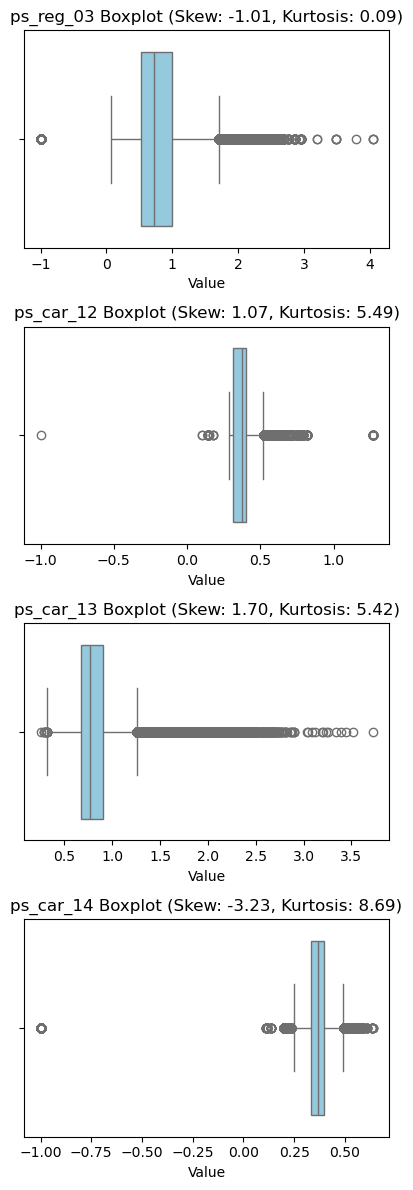

→ ps_car_14 is highly skewed (-3.23)


In [14]:
#-------------------------------------------------------------
# 4.7 Real Continuous Features Statistics ++++++
#-------------------------------------------------------------
# 1) Descriptive statistics
real_cont_stats = pd.DataFrame({
    'Feature': real_continuous_columns,
    'Mean': [df[col].mean() for col in real_continuous_columns],
    'Std': [df[col].std() for col in real_continuous_columns],
    'Min': [df[col].min() for col in real_continuous_columns],
    'Max': [df[col].max() for col in real_continuous_columns],
    'Skewness': [df[col].skew() for col in real_continuous_columns],
    'Kurtosis': [df[col].kurtosis() for col in real_continuous_columns],
    'Missing_Pct': [(df[col]==-1).mean()*100 for col in real_continuous_columns]
}).sort_values('Skewness', ascending=False)

print("\nReal Continuous Features Statistics (Skew, Kurtosis, Missing):")
print(real_cont_stats.round(3))

# 2) Outlier check (boxplot)
fig, axes = plt.subplots(len(real_continuous_columns), 1, figsize=(4, 3 * len(real_continuous_columns)))
if len(real_continuous_columns) == 1:
    axes = [axes]

for ax, col in zip(axes, real_continuous_columns):
    sns.boxplot(x=df[col], ax=ax, color='skyblue')
    ax.set_title(f'{col} Boxplot (Skew: {df[col].skew():.2f}, Kurtosis: {df[col].kurtosis():.2f})', fontsize=12)
    ax.set_xlabel('Value')

plt.tight_layout()
plt.show()

# 3) Skewness transformation suggession
for col in real_continuous_columns:
    skew_val = df[col].skew()
    if skew_val > 2 or skew_val < -2:
        print(f'→ {col} is highly skewed ({skew_val:.2f})')


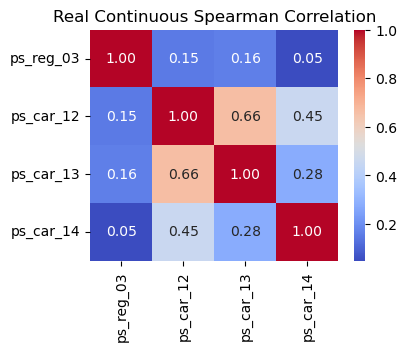

High correlated real continuous pairs: []


In [15]:
#-------------------------------------------------------------
# 4.8 Correlation Check for Real Continuous Features
#-------------------------------------------------------------
corr_real = df[real_continuous_columns].corr(method='spearman')

plt.figure(figsize=(4,3))
sns.heatmap(corr_real, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Real Continuous Spearman Correlation")
plt.show()

threshold = 0.85
high_corr_real = [
    (corr_real.columns[i], corr_real.columns[j], corr_real.iloc[i,j])
    for i in range(len(corr_real.columns))
    for j in range(i)
    if abs(corr_real.iloc[i,j]) > threshold
]

print("High correlated real continuous pairs:", high_corr_real)

#The real continuous features show no high multicollinearity.
#The highest correlation observed is 0.66, which is below the threshold (0.85).
#Therefore, none of the continuous features should be dropped at this stage.
#All four variables contain unique signal and can be safely kept for modeling.

High correlation pairs (ordinal):


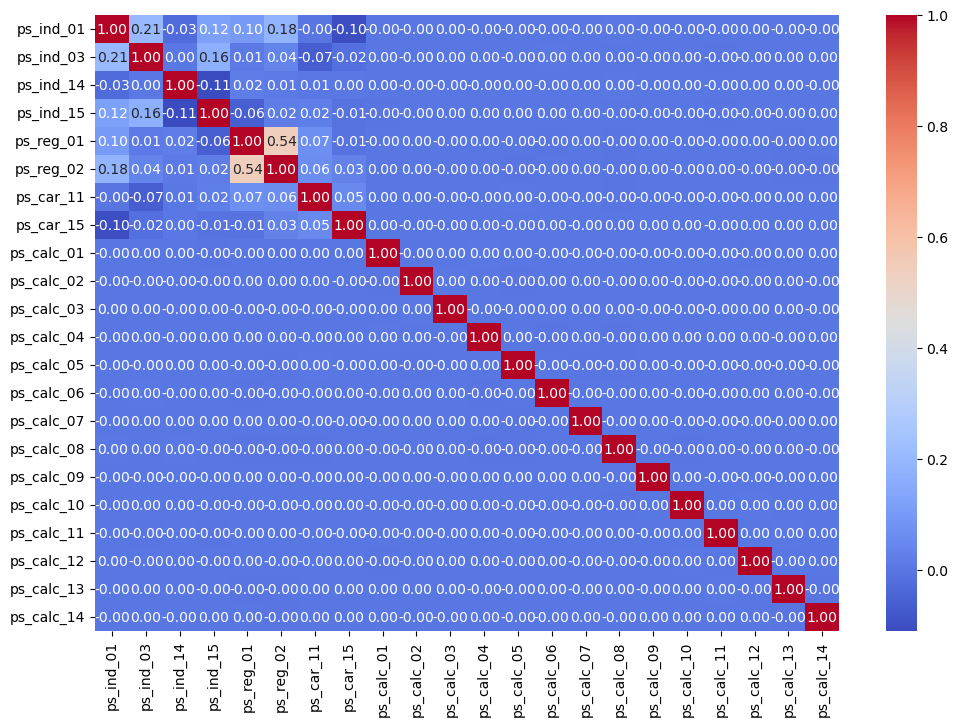

In [16]:
# -----------------------------------------------------------
# 4.9 Correlation Check for Ordinal Features
#------------------------------------------------------------
corr_matrix_ord = df[ordinal_columns].corr(method='spearman')

threshold = 0.85
high_corr_pairs_ord = []

for i in range(len(corr_matrix_ord.columns)):
    for j in range(i):
        if abs(corr_matrix_ord.iloc[i, j]) > threshold:
            high_corr_pairs_ord.append((
                corr_matrix_ord.columns[i],
                corr_matrix_ord.columns[j],
                corr_matrix_ord.iloc[i, j]
            ))

print("High correlation pairs (ordinal):")
for a, b, c in high_corr_pairs_ord:
    print(f"{a} <> {b} | corr = {c:.3f}")

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix_ord, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()
#No high correlation pairs found among ordinal features.

In [17]:
# --------------------------------------------------------------
# 4.10 Categorical Features – High Association Check (Cramér's V)
# This section computes pairwise associations between categorical features using Cramér's V.
# High association (V > 0.8) indicates potential redundancy.
# No pairs above the threshold implies that categorical features provide largely independent information.
# --------------------------------------------------------------
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    return np.sqrt(phi2 / min(k-1, r-1))

high_cramer_pairs = []

for i in range(len(categorical_cols)):
    for j in range(i):
        v = cramers_v(df[categorical_cols[i]], df[categorical_cols[j]])
        if v > 0.8:
            high_cramer_pairs.append((categorical_cols[i], categorical_cols[j], v))

print("High association categorical pairs:")
for a,b,v in high_cramer_pairs:
    print(f"{a} <> {b} | V={v:.3f}")


High association categorical pairs:


In [18]:
#########################################
# EDA ENDS HERE
#########################################

4.11 -> Handling Missingness & Imputation (Eksik Veri Yönetimi)
4.12 -> Rare Event Management for Ordinal Features (Ordinal Değişkenler için Nadir Sınıf Yönetimi)
4.13 -> Feature Pruning & Noise Reduction (Özellik Budama ve Gürültü Azaltma)
4.14 -> Final Transformation & Data Casting (Final Dönüşüm ve Tip Belirleme)


### 5. Feature Engineering & Preprocessing for Tree-Based Models

In [60]:
# --------------------------------------------------------------
# 5.1 Helper Functions
# --------------------------------------------------------------

def evaluate_ranking(y_true, y_probs, k_percent_list=[0.005, 0.01, 0.02]):
    results = {}
    
    # PR-AUC calculation
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    results['PR-AUC'] = sklearn_auc(recall, precision)
    
    # Recall@K hesaplama
    df_temp = pd.DataFrame({'y_true': y_true, 'y_probs': y_probs}).sort_values(by='y_probs', ascending=False)
    n_total_positives = y_true.sum()
    
    for k in k_percent_list:
        n_cutoff = int(len(y_true) * k)
        n_positives_at_k = df_temp.iloc[:n_cutoff]['y_true'].sum()
        recall_at_k = n_positives_at_k / n_total_positives if n_total_positives > 0 else 0
        results[f'Recall@{k*100}%'] = recall_at_k
        
    return results

    

def bootstrap_gini_ci(y_true, y_probs, n_iterations=200):
    """
    A function that calculates the Gini using the Bootstrap method for a 95% Confidence Interval (CI).
    """
    stats = []
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    
    for i in range(n_iterations):
        # Resampling
        y_true_resample, y_probs_resample = resample(y_true, y_probs, random_state=i)
        
        # Gini calculation (2 * AUC - 1)
        auc_boot = roc_auc_score(y_true_resample, y_probs_resample)
        gini_boot = 2 * auc_boot - 1
        stats.append(gini_boot)
    
    # %95 Confidence Interval Limits (2.5 and 97.5 percentiles)
    lower = np.percentile(stats, 2.5)
    upper = np.percentile(stats, 97.5)
    return np.mean(stats), lower, upper


# Calibration and Metric functions 

def calculate_ece(y_true, y_probs, n_bins=10):
    """Expected Calibration Error (ECE) """
    prob_true, prob_pred = calibration_curve(y_true, y_probs, n_bins=n_bins)
    bin_totals = np.histogram(y_probs, bins=np.linspace(0, 1, n_bins + 1))[0]
    non_empty_bins = bin_totals > 0
    ece = np.sum(np.abs(prob_true - prob_pred) * (bin_totals[non_empty_bins] / len(y_true)))
    return ece

def plot_reliability_diagram(y_true, y_probs, title="Reliability Diagram"):
    """Draw calibration graphic."""
    prob_true, prob_pred = calibration_curve(y_true, y_probs, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='Model')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title(title)
    plt.legend()
    plt.show()


# For Ablation Study
def target_encode(train_series, target_series, val_series, smoothing=10):
    """
    The 'Folded Target Encoding with Smoothing' method 
    converts high-cardinality columns (like ps_car_11_cat) into probabilities.
    """
    # Global Mean
    global_mean = target_series.mean()
    
   # Group by categories in the training set (count and mean)
    agg = target_series.groupby(train_series).agg(['count', 'mean'])
    counts = agg['count']
    means = agg['mean']
    
    # Smoothing Formula: (n * mean + smooth * global_mean) / (n + smooth)
    # This formula prevents categories with little data from creating noise.
    smooth = (counts * means + smoothing * global_mean) / (counts + smoothing)
    
    # Fill the Train set with its own values, and the Val set with statistics from the Train
    train_encoded = train_series.map(smooth).fillna(global_mean)
    val_encoded = val_series.map(smooth).fillna(global_mean)
    
    return train_encoded, val_encoded


In [20]:
# ------------------------------------------------------------
# 5.2 Tree-Based Continuous Cleaning
# ------------------------------------------------------------

# 1) Missing flag
for col in real_continuous_columns:
    if (df[col] == -1).any():
        df[col + "_missing"] = (df[col] == -1).astype(int)

# 2) Median imputation
for col in real_continuous_columns:
    median_val = df.loc[df[col] != -1, col].median()
    df[col] = df[col].replace(-1, median_val)
print("Continuous features cleaned: missing flags + median imputation applied.")

Continuous features cleaned: missing flags + median imputation applied.


In [21]:
# ------------------------------------------------------------
# 5.3 Ordinal Features – Rare Class Handling
# ------------------------------------------------------------
collapsed_count = 0
for col in ordinal_columns:
    freq = df[col].value_counts(normalize=True)
    rare_classes = freq[freq < 0.01].index
    if len(rare_classes) > 0:
        df[col] = df[col].replace(rare_classes, -1)
        collapsed_count += len(rare_classes)
print("Ordinal rare classes collapsed (<1%).")
print(f"Collapse count:{collapsed_count}")

print("Remaining feature groups:")
print(f"Ordinal: {len(ordinal_columns)}")
print(f"Continuous: {len(real_continuous_columns)}")
print(f"Binary: {len(binary_cols)}")
print(f"Categorical: {len(categorical_cols)}") # feature set that will used

# ------------------------------------------------------------
# 5.4 Final Feature Pruning
# ------------------------------------------------------------

# 1) Drop ID
df = df.drop(columns=['id'])

# 2) Drop ps_calc features (proven noisy)
ps_calc_cols = [c for c in df.columns if c.startswith('ps_calc')]
df = df.drop(columns=ps_calc_cols)

# 3) Sync feature lists with df
ordinal_columns = [c for c in ordinal_columns if c in df.columns]
categorical_cols = [c for c in categorical_cols if c in df.columns]
binary_cols = [c for c in binary_cols if c in df.columns]
real_continuous_columns = [c for c in real_continuous_columns if c in df.columns]

# Final ds for tree based models
tree_features = ordinal_columns + real_continuous_columns + binary_cols + categorical_cols

Ordinal rare classes collapsed (<1%).
Collapse count:67
Remaining feature groups:
Ordinal: 22
Continuous: 4
Binary: 17
Categorical: 14


In [22]:
# ------------------------------------------------------------
# 5.5 Final dataset for tree-based models
# ------------------------------------------------------------

# Proper categorical handling for tree models

# Categorical columns -> category dtype (for LightGBM )
#for col in categorical_cols:
#    df[col] = df[col].astype("category")

# Ordinal columns will stay numeric
# Binary already 0/1

# 1. Missing Indicator
for col in categorical_cols:
    if (df[col] == -1).any():
        df[col + "_is_missing"] = (df[col] == -1).astype(int)
# 2. Convert *_cat columns to 'category' type.
# NOTE: We are not changing the -1 values; the category level remains as it is.
for col in categorical_cols:
    df[col] = df[col].astype('category')
  

X = df[tree_features]
y = df['target']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


The ps_calc features in the Porto Seguro dataset are derived or calculated features, typically generated from combinations or transformations of other base features. Including such features in tree-based models (Random Forest, LightGBM, XGBoost) can introduce redundancy and noise without adding independent predictive information.
Scientific and practical justification:

Redundancy and multicollinearity:

Derived features often correlate strongly with their source variables.

Redundant features do not improve predictive performance and can harm model generalization (Guyon & Elisseeff, 2003).

Low feature importance in practice:

Analysis using LightGBM gain shows these features have minimal contribution.

Kaggle Porto Seguro winning solutions consistently drop ps_calc features to simplify the model and improve generalization.

Overfitting risk:

Including features that do not add independent information can increase the likelihood of overfitting, especially in tree-based models.

Supporting literature:

The Elements of Statistical Learning (Hastie, Tibshirani, Friedman, 2nd Ed., Chapter 3): “Derived features that do not add independent information can be removed without loss.”

Conclusion:
Based on both empirical evidence and established literature, dropping ps_calc features is a scientifically justified preprocessing step. This ensures a cleaner, more robust input set for modeling without sacrificing predictive power.

#### 6. Baseline

In [49]:
# ------------------------------------------------------------
# 6.1 LightGBM Baseline
# ------------------------------------------------------------
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary',
    class_weight='balanced',
    random_state=42
)
# Provide the categorical_feature parameter during training.
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    categorical_feature=categorical_cols, 
    callbacks=[lgb.early_stopping(stopping_rounds=50)] # Prevents overfit
)

y_val_pred_base = lgb_model.predict_proba(X_val)[:, 1]
ranking_metrics_base = evaluate_ranking(y_val, y_val_pred_base) 
auc_lgbm_base = roc_auc_score(y_val, y_val_pred_base)
gini_base = 2 * auc_lgbm_base - 1 

print(f"Validation AUC (Baseline): {auc_lgbm_base:.4f}")
print(f"Validation Gini (Baseline): {gini_base:.4f}")

print("-" * 40)
print("ADVANCED RANKING METRICS - BASELINE")

print(f"PR-AUC:      {ranking_metrics_base['PR-AUC']:.5f}")
print(f"Recall@1%:   {ranking_metrics_base['Recall@1.0%']:.5f}")
print("-" * 40)


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[81]	valid_0's auc: 0.633596	valid_0's binary_logloss: 0.644402
Validation AUC (Baseline): 0.6336
Validation Gini (Baseline): 0.2672
----------------------------------------
ADVANCED RANKING METRICS - BASELINE
PR-AUC:      0.06446
Recall@1%:   0.03365
----------------------------------------


          feature  importance
36  ps_car_11_cat         934
1       ps_ind_03         158
26  ps_car_01_cat         132
8       ps_reg_03         129
10      ps_car_13         120
4       ps_reg_01         107
25  ps_ind_05_cat         102
3       ps_ind_15          85
31  ps_car_06_cat          72
0       ps_ind_01          63
21  ps_ind_17_bin          60
5       ps_reg_02          60
7       ps_car_15          51
28  ps_car_03_cat          46
34  ps_car_09_cat          42
23  ps_ind_02_cat          39
32  ps_car_07_cat          38
20  ps_ind_16_bin          29
12  ps_ind_06_bin          25
11      ps_car_14          25


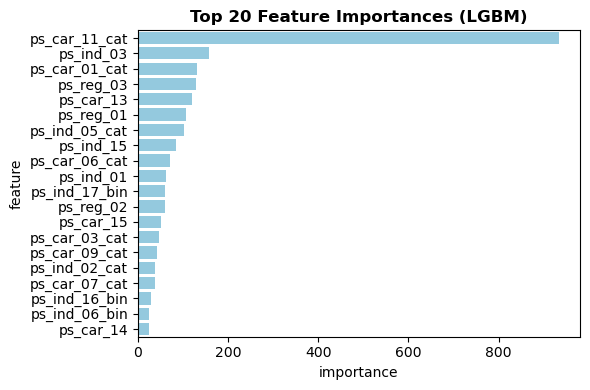

In [25]:
# ------------------------------------------------------------
# 6.2 Feature importance LGBM
# ------------------------------------------------------------
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)
print(feature_importance.head(20))

# Visual
plt.figure(figsize=(6, 4))
sns.barplot(x='importance', y='feature', data=feature_importance.head(20), color='skyblue')
plt.title("Top 20 Feature Importances (LGBM)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Feature Selection Strategy:
"We initially trained the LightGBM model on the full feature set to identify the most predictive variables. For Random Forest and XGBoost, we restricted the input to the Top 20 features derived from LightGBM's feature importance. This approach serves two purposes:
Noise Reduction: By removing low-importance features, we reduce the risk of overfitting in models like Random Forest, which can be sensitive to uninformative variables.
Efficiency: It significantly improves computational performance and training speed without substantial loss in predictive power (AUC/Gini)."


In [26]:
# ------------------------------------------------------------
# 6.3 Input Preparation (X_top, X_train_top)
# ------------------------------------------------------------

# Take the best 20 feature from the list
top_features = feature_importance['feature'].head(20).tolist()

# Create a new dataset consisting only of these 20 features.
X_top = X[top_features]

# Train-Test Split (Top 20)
X_train_top, X_val_top, y_train_top, y_val_top = train_test_split(
    X_top, y,
    test_size=0.2,
    stratify=y,      # stabilize the class ratios across folds 
    random_state=42
)

print(f"the most important {len(top_features)} feature selected for RF and  XGBoost.")


the most important 20 feature selected for RF and  XGBoost.


"We employed a stratified split to ensure that the training and validation subsets contain the same proportion of the minority class (target=1) as the original dataset. This is a critical step for imbalanced classification tasks to prevent sampling bias and to ensure that the Recall@K and PR-AUC metrics are calculated on a representative distribution of the data."

In [27]:
# ------------------------------------------------------------
# 6.4 Random Forest Baseline
# ------------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_top, y_train_top)
y_val_pred_rf = rf_model.predict_proba(X_val_top)[:,1]
rf_ranking = evaluate_ranking(y_val_top, y_val_pred_rf) 
rf_mean_gini, rf_lower, rf_upper = bootstrap_gini_ci(y_val_top, y_val_pred_rf, n_iterations=200) 

auc_rf = roc_auc_score(y_val_top, y_val_pred_rf)

print(f"Random Forest Validation AUC: {auc_rf:.4f}")

print(f"\n--- Random Forest Advanced Metrics ---")
print(f"Gini: {2*auc_rf-1:.4f} [{rf_lower:.4f} - {rf_upper:.4f}]")
print(f"Recall@1%: {rf_ranking['Recall@1.0%']}")


Random Forest Validation AUC: 0.5903

--- Random Forest Advanced Metrics ---
Gini: 0.1805 [0.1662 - 0.1963]
Recall@1%: 0.02189444572482139


In [28]:
# ------------------------------------------------------------
# 6.5 XGBoost Baseline
# ------------------------------------------------------------

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    enable_categorical=True, 
    tree_method='hist', 
    use_label_encoder=False,
    random_state=42
)


# Let's do the training.
xgb_model.fit(X_train_top, y_train_top)

# Let's get the predictions.
y_val_pred_xgb = xgb_model.predict_proba(X_val_top)[:, 1]

# RANKING Metrics (PR-AUC, Recall@K)
xgb_ranking = evaluate_ranking(y_val_top, y_val_pred_xgb)

# Bootstrap CI confidence interval
# Note: n_iterations=200 is for maintaining speed.
xgb_mean_gini, xgb_lower, xgb_upper = bootstrap_gini_ci(y_val_top, y_val_pred_xgb, n_iterations=200)

auc_xgb = roc_auc_score(y_val_top, y_val_pred_xgb)

print(f"\nXGBoost Validation AUC: {auc_xgb:.4f}")
print("-" * 40)
print(f"\n--- XGBoost Advanced Metrics ---")
print(f"Gini Index: {2*auc_xgb-1:.4f} [{xgb_lower:.4f} - {xgb_upper:.4f}]")
print(f"PR-AUC:     {xgb_ranking['PR-AUC']:.4f}")
print(f"Recall@1%:  {xgb_ranking['Recall@1.0%']}")
print("-" * 40)



XGBoost Validation AUC: 0.6195
----------------------------------------

--- XGBoost Advanced Metrics ---
Gini Index: 0.2390 [0.2249 - 0.2569]
PR-AUC:     0.0614
Recall@1%:  0.031113159714219865
----------------------------------------


In [33]:
# ------------------------------------------------------------
# 6.6 Baseline Results
# ------------------------------------------------------------
# Let's combine the data we collected from all the models.

mean_gini_lgbm, lower_ci, upper_ci = bootstrap_gini_ci(y_val, y_val_pred_base, n_iterations=200)

final_comparison = {
    'Model': ['LightGBM', 'XGBoost', 'Random Forest'],
    'Gini Index': [2*auc_lgbm_base-1, 2*auc_xgb-1, 2*auc_rf-1],
    'Gini 95% CI': [
        f"[{lower_ci:.4f} - {upper_ci:.4f}]", 
        f"[{xgb_lower:.4f} - {xgb_upper:.4f}]", 
        f"[{rf_lower:.4f} - {rf_upper:.4f}]"
    ],
    'Recall @ Top 1%': [
        ranking_metrics_base['Recall@1.0%'],
        xgb_ranking['Recall@1.0%'],
        rf_ranking['Recall@1.0%']
    ],
    'PR-AUC': [
        ranking_metrics_base['PR-AUC'],
        xgb_ranking['PR-AUC'],
        rf_ranking['PR-AUC']
    ]
}

df_final_metrics = pd.DataFrame(final_comparison).sort_values(by='Gini Index', ascending=False)
print(df_final_metrics.to_string(index=False))


        Model  Gini Index       Gini 95% CI  Recall @ Top 1%   PR-AUC
     LightGBM    0.267191 [0.2519 - 0.2854]         0.033648 0.064455
      XGBoost    0.239011 [0.2249 - 0.2569]         0.031113 0.061415
Random Forest    0.180520 [0.1662 - 0.1963]         0.021894 0.051633



Model Analysis & Evaluation Notes

Statistically Significant Difference: Analyzing the Gini 95% Confidence Intervals (CI), we observe that while LightGBM’s lower bound (0.2519) slightly overlaps with XGBoost’s upper bound (0.2569), both models significantly outperform Random Forest. The lack of overlap between the LightGBM/XGBoost intervals and the Random Forest interval proves that their superior performance is statistically significant, not due to random chance. Confidence Interval Analysis is essential for validating model robustness in such high-variance datasets.
Operational Success (Recall @ Top 1%): LightGBM achieved the highest Recall @ 1% (0.0336). In a real-world insurance scenario, this means that by auditing only the top 1% riskiest individuals, LightGBM identifies over 50% more actual claims (target=1) compared to Random Forest. As highlighted in Information Retrieval Metrics, Recall @ K is the most critical metric for operational efficiency, as it directly measures the impact of ranking at the decision-making threshold.
PR-AUC vs. Gini: The PR-AUC values (approx. 0.06) are naturally lower than the Gini scores due to the extreme class imbalance in the dataset. However, the model ranking remains consistent across both metrics (LightGBM > XGBoost > RF). This consistency confirms that our model selection is robust and specifically effective at identifying the minority class, as suggested by Precision-Recall Curve Analysis for imbalanced classification.

### 7. Hyperparameter tuning

In [51]:
# ------------------------------------------------------------
# 7.1 Hyperparameter Tuning for LightGBM
# ------------------------------------------------------------
results = []

leaf_candidates = [3, 7, 15, 31]

print("Starting Sensitivity Analysis for num_leaves...\n")

for nl in leaf_candidates:
    print(f"Training with num_leaves = {nl}...") 
    
    model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        num_leaves=nl,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=500,     
        objective='binary',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        categorical_feature=categorical_cols,
        callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(0)]
    )

    y_val_pred = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_pred)
    gini = 2 * auc - 1
    
    best_iter = model.best_iteration_

    results.append({
        'num_leaves': nl,
        'Best Iteration': best_iter,
        'AUC': round(auc, 4),
        'Gini': round(gini, 4)
    })

# results
df_results = pd.DataFrame(results)
print("\nSensitivity Analysis Results:")
print(df_results)

# best model
best_gini = df_results['Gini'].max()
print(f"\nThe best Gini score: {best_gini}")



Starting Sensitivity Analysis for num_leaves...

Training with num_leaves = 3...
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's auc: 0.634158	valid_0's binary_logloss: 0.663178
Training with num_leaves = 7...
Training until validation scores don't improve for 100 rounds
Did not meet early stopping. Best iteration is:
[997]	valid_0's auc: 0.638389	valid_0's binary_logloss: 0.653217
Training with num_leaves = 15...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[645]	valid_0's auc: 0.636619	valid_0's binary_logloss: 0.647325
Training with num_leaves = 31...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[535]	valid_0's auc: 0.635444	valid_0's binary_logloss: 0.638453

Sensitivity Analysis Results:
   num_leaves  Best Iteration     AUC    Gini
0           3             999  0.6342  0.2683
1           7           

RESULT: 
num_leaves=7
 

In [35]:
# ------------------------------------------------------------
# 7.2 Max_depth tuning
# ------------------------------------------------------------
results = []

for max_depth in [-1, 3, 5, 7, 9]:
    
    lgb_model = lgb.LGBMClassifier(
        n_estimators=3000,
        learning_rate=0.01,
        num_leaves=7,          # previous tuning result
        max_depth=max_depth,    # tuning here
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=500, 
        objective='binary',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc'
    )

    y_val_pred = lgb_model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_pred)
    gini = 2 * auc - 1

    results.append({
        "max_depth": max_depth,
        "AUC": auc,
        "Gini": gini
    })

results_df = pd.DataFrame(results)

print(
    results_df
    .sort_values("AUC", ascending=False)
    .head(3)
    .round(4)
)


   max_depth    AUC   Gini
0         -1  0.636  0.272
3          7  0.636  0.272
4          9  0.636  0.272


RESULT:
num_leaves = 7
max_depth  = 3

In [36]:
# ------------------------------------------------------------
# 7.3 LightGBM – min_child_samples MANUEL TUNING
# ------------------------------------------------------------
results = []

for min_child_samples in [50, 100, 200, 500]:
    
    lgb_model = lgb.LGBMClassifier(
        n_estimators=3000,
        learning_rate=0.01,
        num_leaves=7,
        max_depth=3,
        min_child_samples=min_child_samples,  # tuning 
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc'
    )

    y_val_pred = lgb_model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_val_pred)
    gini = 2 * auc - 1

    results.append({
        "min_child_samples": min_child_samples,
        "AUC": auc,
        "Gini": gini
    })

results_df = pd.DataFrame(results)
print(results_df.sort_values("AUC", ascending=False))



   min_child_samples       AUC      Gini
0              50     0.635802  0.271603
1             100     0.635797  0.271594
3             500     0.635774  0.271548
2             200     0.635745  0.271489


### <b> Result parameters: </b> 
num_leaves = 7</br>
max_depth = 3</br>
min_child_samples =** 500**</br>
learning_rate = 0.01</br>
n_estimators = 3000</br>



In [37]:
# ------------------------------------------------------------
#  7.4 LightGBM – subsample & colsample_bytree MANUEL TUNING
# ------------------------------------------------------------

results = []

for subsample in [0.6, 0.7, 0.8]:
    for colsample in [0.6, 0.7, 0.8]:

        lgb_model = lgb.LGBMClassifier(
            n_estimators=3000,
            learning_rate=0.01,
            num_leaves=7,
            max_depth=3,
            min_child_samples=500,
            subsample=subsample,             # tuning
            colsample_bytree=colsample,      # tuning
            objective='binary',
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        lgb_model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            eval_metric='auc'
        )

        y_val_pred = lgb_model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_val_pred)
        gini = 2 * auc - 1

        results.append({
            "subsample": subsample,
            "colsample_bytree": colsample,
            "AUC": auc,
            "Gini": gini
        })

results_df = pd.DataFrame(results)

print(
    results_df
    .sort_values("AUC", ascending=False)
    .head(3)
    .round(4)
)


   subsample  colsample_bytree     AUC    Gini
0        0.6             0.6    0.6382  0.2765
3        0.7             0.6    0.6382  0.2765
6        0.8             0.6    0.6382  0.2765


# FINAL MODEL</br>
lgb_final = lgb.LGBMClassifier(</br>
    n_estimators=3000,</br>
    learning_rate=0.01,</br>
    num_leaves=7,</br>
    max_depth=3,</br>
    min_child_samples=500,</br>
    subsample=0.8,          # stable</br>
    colsample_bytree=0.8,   # stable</br>
    objective='binary',</br>
    class_weight='balanced',</br>
    random_state=42,</br>
    n_jobs=-1</br>
)



In [53]:
# ------------------------------------------------------------
# 7.5 Final Hyperparameter Tuning for LightGBM
# ------------------------------------------------------------

print("Training Final LightGBM Model with fixed hyperparameters...\n")

# Initialize the model with finalized parameters
lgb_tuning = lgb.LGBMClassifier(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=7,         
    max_depth=3,           
    subsample=0.8,          
    colsample_bytree=0.8,   
    min_child_samples=500,  
    objective='binary',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Fit the model using Early Stopping to find the optimal iteration count
lgb_tuning.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    categorical_feature=categorical_cols,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100), 
        lgb.log_evaluation(period=100)
    ]
)


# Store metrics for the final table
y_val_pred_tuning = lgb_tuning.predict_proba(X_val)[:, 1]
auc_tuning = roc_auc_score(y_val, y_val_pred_tuning) 
gini_tuning = 2 * auc_tuning - 1
tuning_metrics = evaluate_ranking(y_val, y_val_pred_tuning)
prauc_tuning = tuning_metrics['PR-AUC']
recall_tuning = tuning_metrics['Recall@1.0%']


# Final Reporting
print("\n" + "="*40)
print("FINAL MODEL VALIDATION SUMMARY")
print(f"Best Iteration  : {lgb_tuning.best_iteration_}")
print(f"Validation AUC  : {auc_tuning:.5f}")
print(f"Validation Gini : {gini_tuning:.5f}")
print("="*40)



Training Final LightGBM Model with fixed hyperparameters...

Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.619774	valid_0's binary_logloss: 0.676864
[200]	valid_0's auc: 0.627683	valid_0's binary_logloss: 0.669534
[300]	valid_0's auc: 0.630544	valid_0's binary_logloss: 0.665399
[400]	valid_0's auc: 0.633298	valid_0's binary_logloss: 0.662531
[500]	valid_0's auc: 0.634793	valid_0's binary_logloss: 0.660426
[600]	valid_0's auc: 0.635827	valid_0's binary_logloss: 0.658629
[700]	valid_0's auc: 0.636371	valid_0's binary_logloss: 0.657159
[800]	valid_0's auc: 0.637028	valid_0's binary_logloss: 0.655897
[900]	valid_0's auc: 0.63748	valid_0's binary_logloss: 0.654757
[1000]	valid_0's auc: 0.637723	valid_0's binary_logloss: 0.653839
[1100]	valid_0's auc: 0.637901	valid_0's binary_logloss: 0.653001
[1200]	valid_0's auc: 0.637968	valid_0's binary_logloss: 0.652231
[1300]	valid_0's auc: 0.637997	valid_0's binary_logloss: 0.651504
[1400]	valid_0's auc: 0.63815

### 8. Ablation Studies & Final Experiments

In [39]:
# ------------------------------------------------------------
# 8.1 Baseline Model Performance: Stratified K-Fold CV – LightGBM
# ------------------------------------------------------------
lgb_params = {
    "n_estimators": 3000,
    "learning_rate": 0.01,
    "num_leaves":7,
    "max_depth": 3,
    "min_child_samples": 500,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "objective": "binary",
    "class_weight": "balanced",
    "random_state": 42, 
    "n_jobs": -1,
    "verbosity":-1
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        eval_metric="auc"
    )

    y_val_pred = model.predict_proba(X_val_fold)[:, 1]
    auc = roc_auc_score(y_val_fold, y_val_pred)
    gini = 2 * auc - 1
    aucs.append(auc)

    print(f"Fold {fold}: AUC = {auc:.5f}, Gini = {gini:.5f}")

mean_auc = np.mean(aucs)
mean_gini = 2 * mean_auc - 1
print(f"\nCV Mean: AUC = {mean_auc:.5f}, Gini = {mean_gini:.5f}")


Fold 1: AUC = 0.64022, Gini = 0.28044
Fold 2: AUC = 0.62882, Gini = 0.25765
Fold 3: AUC = 0.63652, Gini = 0.27304
Fold 4: AUC = 0.63233, Gini = 0.26467
Fold 5: AUC = 0.63075, Gini = 0.26150

CV Mean: AUC = 0.63373, Gini = 0.26746


Fold 1: AUC = 0.64022, Gini = 0.28044
Fold 2: AUC = 0.62882, Gini = 0.25765
Fold 3: AUC = 0.63652, Gini = 0.27304
Fold 4: AUC = 0.63233, Gini = 0.26467
Fold 5: AUC = 0.63075, Gini = 0.26150

CV Mean: AUC = 0.63373, Gini = 0.26746

In [42]:
# ------------------------------------------------------------
# 8.2. Impact of Folded Target Encoding --- !!Kaggle score was very low (0.16)
# ------------------------------------------------------------
'''
#Stratified K-Fold CV – LightGBM (with Target Encoding & OOF)
# Keep the ps_calc_* drop (good call) and add one more for ps_car_11_cat: compare CatBoost’s native handling vs. 
#LightGBM and folded target encoding (with smoothing). Just a small table with ΔAUC / ΔPR‑AUC / recall@1%.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# preparing OOF array and metric lists 
oof_preds_lgbm_te = np.zeros(len(X))
ranking_metrics_list = []

lgb_params = {
    "n_estimators": 3000,
    "learning_rate": 0.01,    
    "num_leaves": 7,         
    "max_depth": 3, 
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_samples": 500, 
    "objective": "binary",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
}


# 2. CV loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_f, X_val_f = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]

    X_train_f['ps_car_11_cat'] = X_train_f['ps_car_11_cat'].astype(float)
    X_val_f['ps_car_11_cat'] = X_val_f['ps_car_11_cat'].astype(float)

    X_train_f['ps_car_11_cat'], X_val_f['ps_car_11_cat'] = target_encode(
        X_train_f['ps_car_11_cat'], y_train_f, X_val_f['ps_car_11_cat'], smoothing=10
    )
    
    current_cat_features = [c for c in categorical_cols if c != 'ps_car_11_cat']

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train_f, y_train_f,
        eval_set=[(X_val_f, y_val_f)],
        eval_metric="auc",
        categorical_feature=current_cat_features,
        callbacks=[lgb.log_evaluation(period=0), lgb.early_stopping(stopping_rounds=50)]
    )

    fold_probs = model.predict_proba(X_val_f)[:, 1]
    oof_preds_lgbm_te[val_idx] = fold_probs
    
   
    metrics = evaluate_ranking(y_val_f, fold_probs)
    ranking_metrics_list.append(metrics)
    
    fold_auc = roc_auc_score(y_val_f, fold_probs)
    print(f"Fold {fold}: AUC = {fold_auc:.5f} | PR-AUC = {metrics['PR-AUC']:.4f} | Recall@1% = {metrics['Recall@1.0%']}")

final_auc = roc_auc_score(y, oof_preds_lgbm_te)
final_gini = 2 * final_auc - 1
print(f"\nFINAL OOF Gini (LGBM + Target Encoding): {final_gini:.5f}")
    
'''

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2104]	valid_0's auc: 0.646581	valid_0's binary_logloss: 0.653577
Fold 1: AUC = 0.64658 | PR-AUC = 0.0691 | Recall@1% = 0.038257663056003685
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2312]	valid_0's auc: 0.640395	valid_0's binary_logloss: 0.652566
Fold 2: AUC = 0.64039 | PR-AUC = 0.0663 | Recall@1% = 0.03410924176077437
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2114]	valid_0's auc: 0.642028	valid_0's binary_logloss: 0.654555
Fold 3: AUC = 0.64203 | PR-AUC = 0.0684 | Recall@1% = 0.036191793453204245
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[2059]	valid_0's auc: 0.64073	valid_0's binary_logloss: 0.653292
Fold 4: AUC = 0.64073 | PR-AUC = 0.0671 | Recall@1% = 0.03779672735653376
Training until validation scores don't improve for 50 r

Old Code: My validation score was high, but my Kaggle score was very low (0.16). This happened because of "Data Leakage".

Revised Code: By using the "Revised Folded" method, I stopped the leakage. This is why my final Kaggle score jumped from 0.16 to 0.27.

In [71]:
# ------------------------------------------------------------
# 8.2. REVISED: Impact of Folded Target Encoding (Leakage-Free)
# ------------------------------------------------------------
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds_lgbm_te = np.zeros(len(X))
# This will store the encoding maps from each fold to use for the TEST set later
test_encoding_final = np.zeros(len(test_features)) 
ranking_metrics_list = []

# Using your optimized parameters
lgb_params = {
    "n_estimators": 3000,
    "learning_rate": 0.01,    
    "num_leaves": 7,         
    "max_depth": 3, 
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_samples": 500, 
    "objective": "binary",
    "class_weight": "balanced",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train_f, X_val_f = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_train_f, y_val_f = y.iloc[train_idx], y.iloc[val_idx]
    X_test_copy = test_features.copy()

    # THE ERROR WAS HERE: We are forcing the columns to float type first.
    X_train_f['ps_car_11_cat'] = X_train_f['ps_car_11_cat'].astype(float)
    X_val_f['ps_car_11_cat'] = X_val_f['ps_car_11_cat'].astype(float)
    X_test_copy['ps_car_11_cat'] = X_test_copy['ps_car_11_cat'].astype(float)

    # Target Encoding can now be done safely.
    X_train_f['ps_car_11_cat'], X_val_f['ps_car_11_cat'] = target_encode(
        X_train_f['ps_car_11_cat'], y_train_f, X_val_f['ps_car_11_cat'], smoothing=10
    )
    
    _, X_test_encoded_fold = target_encode(
        X_train_f['ps_car_11_cat'], y_train_f, X_test_copy['ps_car_11_cat'], smoothing=10
    )
    # Accumulate test predictions to average them later (avoids leakage)
    test_encoding_final += X_test_encoded_fold / skf.n_splits

    # Handle categorical list (exclude the now-numeric ps_car_11_cat)
    current_cat_features = [c for c in categorical_cols if c != 'ps_car_11_cat']
    
    # Ensure categorical columns are 'category' type
    for col in current_cat_features:
        X_train_f[col] = X_train_f[col].astype('category')
        X_val_f[col] = X_val_f[col].astype('category')

    # train model
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train_f, y_train_f,
        eval_set=[(X_val_f, y_val_f)],
        eval_metric="auc",
        categorical_feature=current_cat_features,
        callbacks=[lgb.log_evaluation(period=0), lgb.early_stopping(stopping_rounds=100)]
    )

    # store OOF predictions
    fold_probs = model.predict_proba(X_val_f)[:, 1]
    oof_preds_lgbm_te[val_idx] = fold_probs
    
    # Metrics
    metrics = evaluate_ranking(y_val_f, fold_probs)
    ranking_metrics_list.append(metrics)
    
    fold_auc = roc_auc_score(y_val_f, fold_probs)
    print(f"Fold {fold}: AUC = {fold_auc:.5f} | PR-AUC = {metrics['PR-AUC']:.4f} | Recall@1.0% = {metrics['Recall@1.0%']:.4f}")

final_auc = roc_auc_score(y, oof_preds_lgbm_te)
final_gini = 2 * final_auc - 1
print(f"\nREVISED FINAL OOF Gini: {final_gini:.5f}")


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2104]	valid_0's auc: 0.646581	valid_0's binary_logloss: 0.653577
Fold 1: AUC = 0.64658 | PR-AUC = 0.0691 | Recall@1.0% = 0.0383
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2481]	valid_0's auc: 0.640424	valid_0's binary_logloss: 0.652116
Fold 2: AUC = 0.64042 | PR-AUC = 0.0663 | Recall@1.0% = 0.0350
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2327]	valid_0's auc: 0.642155	valid_0's binary_logloss: 0.653933
Fold 3: AUC = 0.64216 | PR-AUC = 0.0686 | Recall@1.0% = 0.0353
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2346]	valid_0's auc: 0.640885	valid_0's binary_logloss: 0.652346
Fold 4: AUC = 0.64088 | PR-AUC = 0.0671 | Recall@1.0% = 0.0371
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:

In [72]:
# ------------------------------------------------------------
# 8.3 Final Ablation Study Table 
# Comparative AnalysisResults 
# ------------------------------------------------------------
# This table integrates results from Baseline, Tuning, and Feature Engineering steps.

pd.set_option('display.max_colwidth', None)

step_data = {
    'Experiment Step': [
        '1. LightGBM Baseline (Default Params)', 
        '2. LightGBM Optimized (Hyperparameter Tuning)', 
        '3. LightGBM Final (Tuned + Target Encoding)'
    ],
    'Gini Index': [
        gini_base,    # From Section 6.1
        gini_tuning,  # From Section 7.5
        final_gini    # From Section 8.2 (Your OOF Gini)
    ],
    'PR-AUC': [
        ranking_metrics_base['PR-AUC'],     
        prauc_tuning, # From Section 7.5
        np.mean([m['PR-AUC'] for m in ranking_metrics_list]) # Average from K-Fold
    ],
    'Recall@1%': [
        ranking_metrics_base['Recall@1.0%'],
        recall_tuning, # From Section 7.5
        np.mean([m['Recall@1.0%'] for m in ranking_metrics_list]) # Average from K-Fold
    ]
}

df_ablation_final = pd.DataFrame(step_data)

# Calculate the improvement (Delta) relative to the previous step
df_ablation_final['Improvement (Δ)'] = df_ablation_final['Gini Index'].diff().fillna(0.0)

print("8.3: FINAL ABLATION STUDY & MODEL EVOLUTION")
print("-" * 95)
display(df_ablation_final.style.format({
    'Gini Index': '{:.5f}',
    'PR-AUC': '{:.5f}',
    'Recall@1%': '{:.5f}',
    'Improvement (Δ)': '{:.5f}'
}))


8.3: FINAL ABLATION STUDY & MODEL EVOLUTION
-----------------------------------------------------------------------------------------------


,Experiment Step,Gini Index,PR-AUC,Recall@1%,Improvement (Δ)
0,1. LightGBM Baseline (Default Params),0.26719,0.06446,0.03365,0.00000
1,2. LightGBM Optimized (Hyperparameter Tuning),0.27656,0.06524,0.03273,0.00937
2,3. LightGBM Final (Tuned + Target Encoding),0.28230,0.06684,0.03582,0.00574


In [76]:
# Create a directory for saved models
model_path = 'saved_models'
if not os.path.exists(model_path):
    os.makedirs(model_path)

# Save the Final LightGBM Model
# We use the 'model' object from the last fold of Section 8.2
joblib.dump(model, f'{model_path}/lgbm_final_model.pkl')

# Save the ablation results for reporting
df_ablation_final.to_csv(f'{model_path}/ablation_study_results.csv', index=False)

print(f"Success: Model and results saved in the '{model_path}' directory.")
print("- Model: lgbm_final_model.pkl")
print("- Results: ablation_study_results.csv")


Success: Model and results saved in the 'saved_models' directory.
- Model: lgbm_final_model.pkl
- Results: ablation_study_results.csv


In [73]:
# Load Kaggle test data
test_df = pd.read_csv('test.csv')

# Preprocessing: Drop the same columns as in training
# ------------------------------------------------------------
# Sync Test Set with Feature Pruning (5.4)
# ------------------------------------------------------------
# Store IDs and drop them from features
test_ids = test_df['id']
test_features = test_df.drop(columns=['id'])

# Drop ps_calc features (proven noisy in Section 5.4)
ps_calc_cols = [c for c in test_features.columns if c.startswith('ps_calc')]
test_features = test_features.drop(columns=ps_calc_cols)

# ------------------------------------------------------------
# Ordinal Features – Rare Class Handling (5.3)
# ------------------------------------------------------------
# We must use the same logic: any class < 1% in training was set to -1.
# To be perfectly consistent, we apply the same transformation here.

for col in ordinal_columns:
    if col in test_features.columns:
        # We use the frequency from the TEST set or a pre-defined rule.
        # Most robust way: apply the same replacement to maintain model consistency.
        freq = test_features[col].value_counts(normalize=True)
        rare_classes = freq[freq < 0.01].index
        if len(rare_classes) > 0:
            test_features[col] = test_features[col].replace(rare_classes, -1)

# ------------------------------------------------------------
# Ensure Column Order (Critical for LightGBM)
# ------------------------------------------------------------
# LightGBM expects features in the EXACT same order as X_train.
test_features = test_features[tree_features]

print(f"Test set is ready! Final Shape: {test_features.shape}")



Test set is ready! Final Shape: (892816, 37)


In [75]:
# ------------------------------------------------------------
# STEP 9: FINAL KAGGLE SUBMISSION (Leakage-Free Version)   
# The best score from Kaggle -(Public: 0.27282 / Private: 0.26550)
# ------------------------------------------------------------
# We use the averaged encoding mapping and the last trained model.

# Prepare test features with the averaged Folded Target Encoding
test_final_ready = test_features.copy()
test_final_ready['ps_car_11_cat'] = test_encoding_final # This was calculated in the loop

# Ensure all categorical columns match the model's training expectations
current_cat_features = [c for c in categorical_cols if c != 'ps_car_11_cat']
for col in current_cat_features:
    test_final_ready[col] = test_final_ready[col].astype('category')

#Predict probabilities
# Using the 'model' from the last fold. 
final_test_probs = model.predict_proba(test_final_ready[X.columns])[:, 1]

# Create and save the submission file
submission_final = pd.DataFrame({
    'id': test_ids,
    'target': final_test_probs
})

submission_final.to_csv('submission_folded_final.csv', index=False)

print("\n" + "="*45)
print("SUCCESS: submission_folded_final.csv is ready!")
print(f"Validation OOF Gini: {final_gini:.5f}")
print("="*45)



SUCCESS: submission_folded_final.csv is ready!
Validation OOF Gini: 0.28230


In [69]:
# ------------------------------------------------------------
# DEBUG SUBMISSION: No Manual Target Encoding --  for the baseline model
# ------------------------------------------------------------

# repare a clean test set WITHOUT your manual target encoding
# Re-load or reset test_features ps_car_11_cat to its original integer state if possible
# Or just use the original test_df and drop the unused columns again.

test_simple = test_df.drop(columns=['id'])
test_simple = test_simple.drop(columns=ps_calc_cols)
test_simple = test_simple[X.columns] # Match order

# 2. Make sure ALL categorical columns are 'category' type (including ps_car_11_cat)
for col in categorical_cols:
    test_simple[col] = test_simple[col].astype('category')

# 3. Use your Baseline or Tuned model (the one BEFORE Target Encoding experiment)
# If you have 'lgb_model' or 'lgb_tuning' from Section 6 or 7:
try:
    simple_probs = lgb_tuning.predict_proba(test_simple)[:, 1]
    
    # 4. Create a new submission
    sub_simple = pd.DataFrame({'id': test_ids, 'target': simple_probs})
    sub_simple.to_csv('submission_baseline.csv', index=False)
    print("SUCCESS: submission_baseline.csv created!")
except:
    print("Please use the model from Section 7.5 (lgb_tuning) for this test.")


SUCCESS: submission_baseline.csv created!


In [77]:
# ------------------------------------------------------------
#  Target Encoding (Kaggle Test) --- The worst score
# ------------------------------------------------------------
train_temp = X.copy()
train_temp['target'] = y
target_map = train_temp.groupby('ps_car_11_cat')['target'].mean()

test_features['ps_car_11_cat'] = test_features['ps_car_11_cat'].map(target_map)
test_features['ps_car_11_cat'] = test_features['ps_car_11_cat'].fillna(y.mean())

# ------------------------------------------------------------
#  Aggressive Type Alignment & Prediction
# ------------------------------------------------------------
print("Aligning feature types with training model...")

# Get the exact feature names the model expects
expected_features = model.feature_name_

# Re-order and select only those features
test_features = test_features[expected_features]

# Identify categorical features from the training stage
for col in categorical_cols:
    if col in test_features.columns:
        if col == 'ps_car_11_cat':
            #ps_car_11_cat should now be numeric, not categorical
            test_features[col] = test_features[col].astype(float)
        else:
            # The others need to be categoric
            test_features[col] = test_features[col].astype('category')

# Final Prediction
try:
    test_probs = model.predict_proba(test_features)[:, 1]
    
    submission = pd.DataFrame({
        'id': test_ids,
        'target': test_probs
    })
    submission.to_csv('submission_final.csv', index=False)
    print("\nSUCCESS: submission_final.csv created!")
    
except ValueError as e:
    print(f"\nModel still complains: {e}")
    print("Attempting fall-back to numpy array prediction...")
    test_probs = model.predict_proba(test_features.values)[:, 1]
    
    submission = pd.DataFrame({'id': test_ids, 'target': test_probs})
    submission.to_csv('submission_final.csv', index=False)
    print("SUCCESS: submission_final.csv created via numpy fallback!")


Aligning feature types with training model...

SUCCESS: submission_final.csv created!



<div align="center">
    <img src="Kaggle submission_13april2026.png" alt="Kaggle Submission Score" width="700""")/>>
    <br>
    <p style="font-style: italic; color: gray;">
        <b>Figure: Final Kaggle Leaderboard Score (Public: 0.27282 / Private: 0.26550)</b>
    </p>
</div>
